In [55]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [73]:
class Value:
  def __init__(self, data, _children=(), _op='', label=""):
    self.data = data
    self.grad = 0.0
    self._backward = lambda : None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def _construct_op(self, other, op):
    other = other if isinstance(other, Value) else Value(other)

    if op == "+":
      out =  Value(self.data + other.data, (self, other), '+')
    elif op == "*":
      out =  Value(self.data * other.data, (self, other), '*')

    def _backward():
      if op == "+":
        self.grad += 1.0 * out.grad
        other.grad += 1.0 * out.grad
      elif op == "*":
        self.grad += other.data * out.grad
        other.grad += self.data * out.grad

    out._backward = _backward
    return out

  def __add__(self, other):
    return self._construct_op(other, "+")
  def __radd__(self, other):
    return self.__add__(other)

  def __mul__(self, other):
    return self._construct_op(other, "*")
  def __rmul__(self, other):
    return self.__mul__(other)


  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def backward(self):
    self.grad = 1.0
    topo = []
    visited = set()

    def build_topo(root):
      if root not in visited:
        visited.add(root)
        for child in root._prev:
          build_topo(child)
        topo.append(root)
    build_topo(self)

    for n in reversed(topo):
      n._backward()


In [80]:
a = Value(2.0)
b = 3 + a
b = b * 6
b

Value(data=30.0)

In [57]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for each value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connection n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

In [58]:
# inputs x1,x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1,w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias of the neuron
b = Value(6.8813735870195432, label="b")

# x1*x2 + w1*w2 + b
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + w1*w2"
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label = "o"

In [59]:
o.backward()

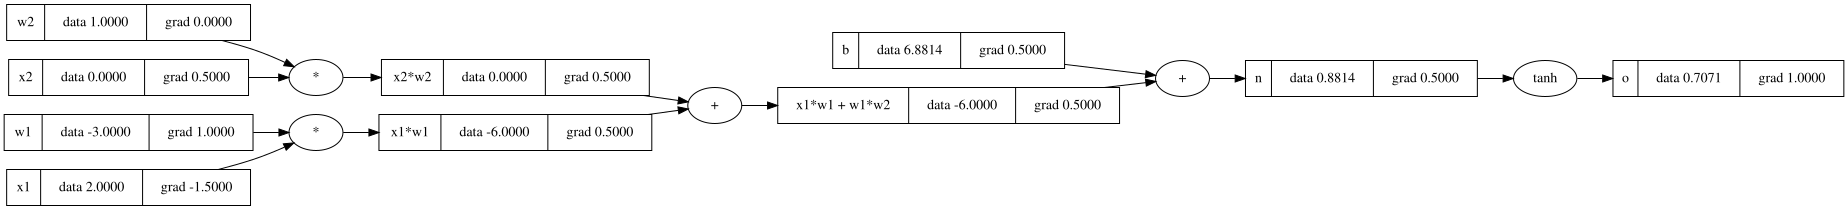

In [60]:

draw_dot(o)